**Inicio del analisis de datos**

*Inica con la recopilacion de los archivos que contienen los datos GPS del Tren Ligero*

In [ ]:
# @title
import pandas as pd
import glob
import os
import re

def consolidar_archivos(directorio, archivo_salida):
    lista_dfs = []

    # Busca todos los archivos .csv en la carpeta especificada
    archivos = sorted(glob.glob(os.path.join(directorio, "*.csv")))

    for archivo in archivos:
       #print(f"Procesando: {archivo}")
        datos_archivo = []
        with open(archivo, 'r', encoding='utf-8') as f:
            lineas = f.readlines()

        # Procesamos en bloques de 3
        for i in range(0, len(lineas), 3):
            if i+2 < len(lineas):
                coords = re.findall(r"[-+]?\d*\.\d+|\d+", lineas[i+1])
                velocidad = re.findall(r"[-+]?\d*\.\d+|\d+", lineas[i+2])

                datos_archivo.append({
                    'Hora': lineas[i].strip(),
                    'Latitud': coords[0] if len(coords) > 0 else None,
                    'Longitud': coords[1] if len(coords) > 1 else None,
                    'Velocidad': velocidad[0] if len(velocidad) > 0 else None
                })

        lista_dfs.append(pd.DataFrame(datos_archivo))

    # Unir todos los DataFrames en uno solo
    if lista_dfs:
        df_final = pd.concat(lista_dfs, ignore_index=True)
        df_final.to_csv(archivo_salida, index=False, encoding='utf-8-sig')
        print(f"\n¡Listo! Todos los datos se han unido en: {archivo_salida}")
    else:
        print("No se encontraron archivos para procesar.")

consolidar_archivos('misArchivos', 'datosCompletos.csv')


¡Listo! Todos los datos se han unido en: datosCompletos.csv


Se realiza una limpieza de los datos separando los caracteres de los datos númerico

In [ ]:
# @title
import pandas as pd
import numpy as np

#Cargar el archivo CSV
datosE = pd.read_csv('datosCompletos.csv')
#Conversión útil para transporte: m/s a km/h
datosE['Velocidad'] = datosE['Velocidad'] * 3.6
#(Opcional) Convertir la columna 'Hora' a formato datetime de Python
# Esto es vital para análisis de series de tiempo
datosE['Hora'] = pd.to_datetime(datosE['Hora'], errors='coerce')
#Seleccionar solo las columnas finales que necesitas para tu modelo de Machine Learning
datos_final = datosE[['Hora', 'Latitud', 'Longitud', 'Velocidad']]
# Agregar CARACTERÍSTICAS para ML
datos_final['dia_semana'] = datos_final['Hora'].dt.dayofweek  # 0=Lunes, 6=Domingo
datos_final['hora_exacta'] = datos_final['Hora'].dt.hour
datos_final['es_fin_de_semana'] = datos_final['dia_semana'].map({0:0, 1:0, 2:0, 3:0, 4:0, 5:1, 6:1})
#Guardar el resultado en un nuevo CSV limpio para tu tesis
datos_final.to_csv('datos_limpios.csv', index=False)
print(datos_final.shape)
print("\n¡Archivo guardado como 'datos_limpios_tren_ligero.csv'!")

(13427, 7)

¡Archivo guardado como 'datos_limpios_tren_ligero.csv'!


Se identifican los datos que son nulos o ceros que no se pueden considerar para ningun tipo de calculo matemático. Además se identifico los datos fuera de rango (velocidad). Grafica

Fuera de rango (Z-score): 30


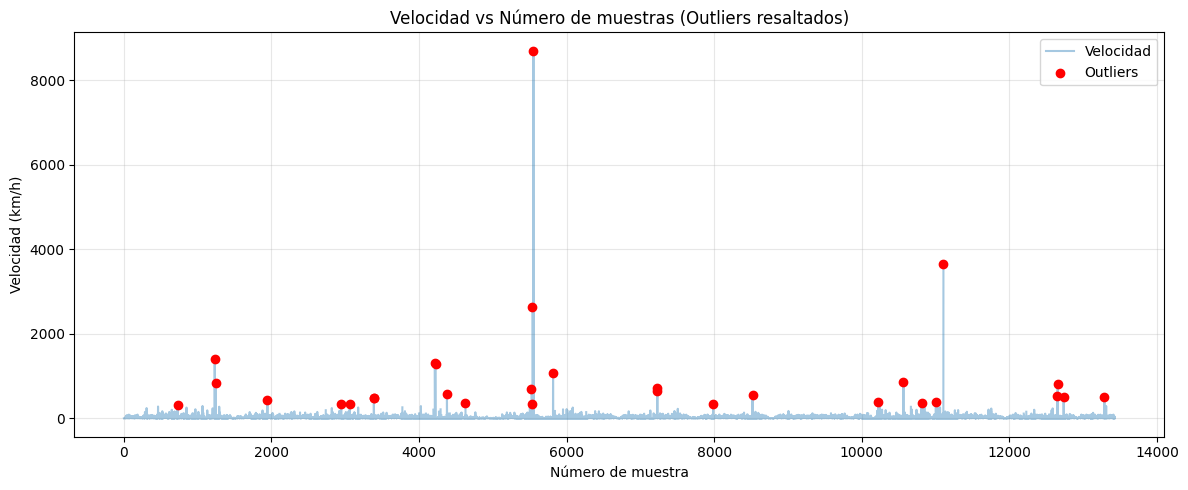

0.0
292.270428
(13397, 8)


In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd

# Cargar datos
df = pd.read_csv("datos_limpios.csv")
# Crear número de muestra
df = df.reset_index(drop=True)
df["Muestra"] = df.index + 1

# DETECCIÓN DE OUTLIERS (Z-score)
def Detecta_Outliers_Z(datos, columna):
    z_scores = stats.zscore(datos[columna], nan_policy="omit")
    return datos[abs(z_scores) > 3]

# Detectar outliers
outliers = Detecta_Outliers_Z(df, "Velocidad")
print(f"Fuera de rango (Z-score): {len(outliers)}")
# GRÁFICA VELOCIDAD VS NÚMERO DE MUESTRAS
plt.figure(figsize=(12, 5))
# Serie completa
plt.plot(df["Muestra"], df["Velocidad"],
         alpha=0.4, label="Velocidad")
# Outliers resaltados
plt.scatter(
    outliers["Muestra"],
    outliers["Velocidad"],
    color="red",
    label="Outliers",
    zorder=3)

plt.xlabel("Número de muestra")
plt.ylabel("Velocidad (km/h)")
plt.title("Velocidad vs Número de muestras (Outliers resaltados)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Eliminar outliers
df_filtrado = df[~df["Muestra"].isin(outliers["Muestra"])]
print(df_filtrado["Velocidad"].min())
print(df_filtrado["Velocidad"].max())
print(df_filtrado.shape)

Al destacar los datos atipicos, se normalizaron los datos, para demostrarlo se realizo una graficas normalizados vs sin normalizar. (se utilizó el método max-min scaling).

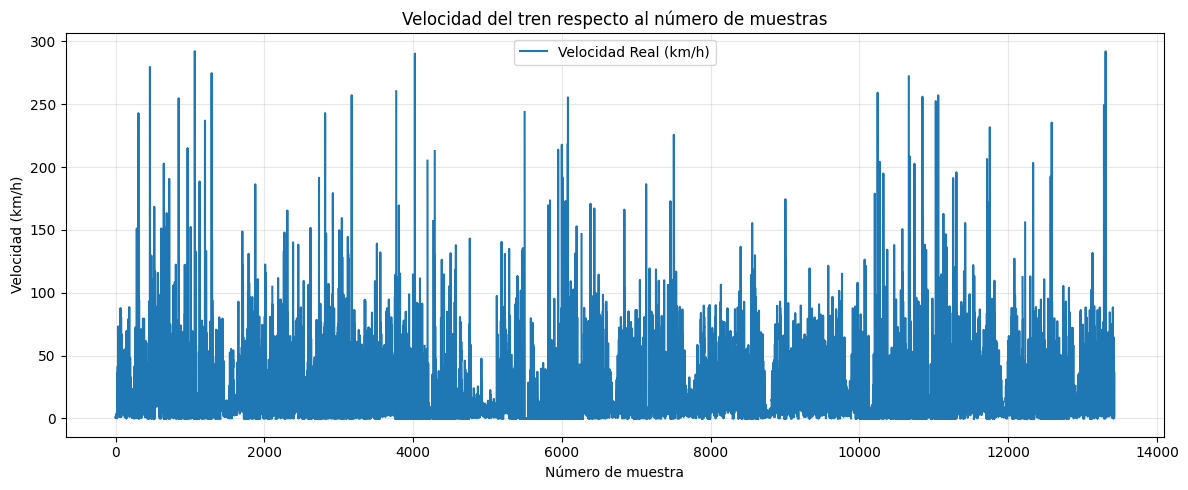

(13397, 8)


In [ ]:
# @title
# Grafica de la velocidad respecto al número de muestras
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(12,5))

# Graficar usando el índice como número de muestra
plt.plot(df_filtrado.index, df_filtrado["Velocidad"],
         label="Velocidad Real (km/h)")

# Etiquetas
plt.title("Velocidad del tren respecto al número de muestras")
plt.xlabel("Número de muestra")
plt.ylabel("Velocidad (km/h)")

# Extras
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
print(df_filtrado.shape)

Límite inferior IQR: -42.10 km/h
Límite superior IQR: 77.39 km/h


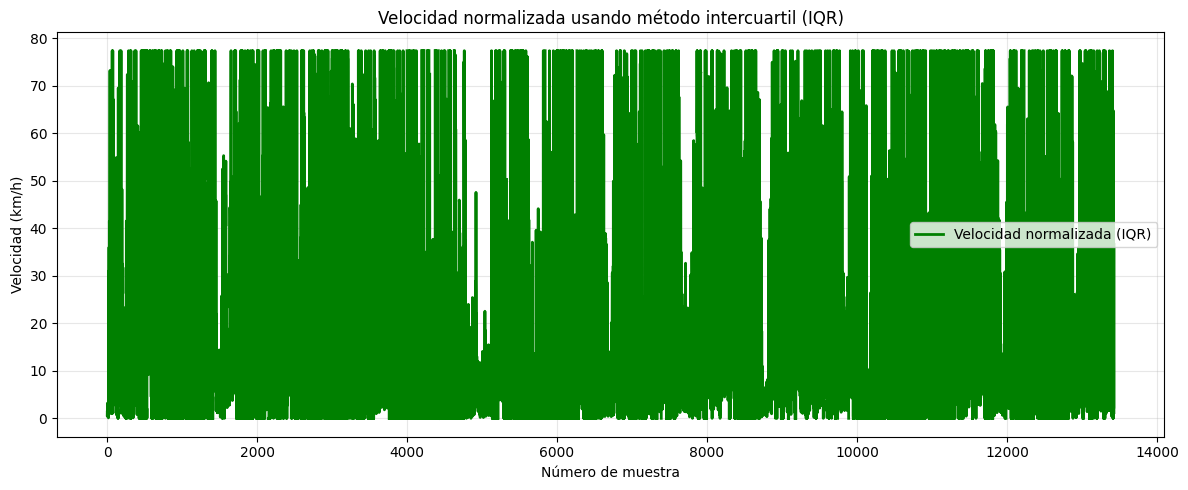

Datos procesados guardados en: datos_limpios.csv
Estadísticas de la velocidad suavizada (IQR):
count    12361.000000
mean        20.709506
std         22.235535
min          0.000000
25%          2.707578
50%         12.488918
75%         32.580302
max         77.389388
Name: Velocidad, dtype: float64
(13427, 8)


In [ ]:
# @title
# PREPROCESAMIENTO DE VELOCIDAD GPS MÉTODO INTERCUARTIL (IQR)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("datos_limpios.csv")
# Crear número de muestra
df = df.reset_index(drop=True)
df["Muestra"] = df.index + 1
# 2. Método intercuartil (IQR)

Q1 = df["Velocidad"].quantile(0.25)
Q3 = df["Velocidad"].quantile(0.75)
IQR = Q3 - Q1
# Límites intercuartiles
LIM_INF = Q1 - 1.5 * IQR
LIM_SUP = Q3 + 1.5 * IQR
print(f"Límite inferior IQR: {LIM_INF:.2f} km/h")
print(f"Límite superior IQR: {LIM_SUP:.2f} km/h")

# Ajuste de valores extremos (winsorización por IQR)
df["Velocidad_corr"] = df["Velocidad"].copy()
df.loc[df["Velocidad_corr"] < LIM_INF, "Velocidad_corr"] = LIM_INF
df.loc[df["Velocidad_corr"] > LIM_SUP, "Velocidad_corr"] = LIM_SUP
#Eliminar columnas y renombrar
df = df.drop(["Velocidad"], axis=1)
df = df.rename(columns={"Velocidad_corr": "Velocidad"})
# 4. Gráfica: Velocidad suavizada vs Número de muestras
plt.figure(figsize=(12, 5))
plt.plot(df["Muestra"], df["Velocidad"],
         color="green", linewidth=2,
         label="Velocidad normalizada (IQR)")
plt.xlabel("Número de muestra")
plt.ylabel("Velocidad (km/h)")
plt.title("Velocidad normalizada usando método intercuartil (IQR)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 5. Guardar datos procesados
archivo_salida = "datos_limpios.csv"
df.to_csv(archivo_salida, index=False)
print(f"Datos procesados guardados en: {archivo_salida}")
# 6. Estadísticas finales
# ------------------------------
print("Estadísticas de la velocidad suavizada (IQR):")
print(df["Velocidad"].describe())
print(df.shape)

Identificacion de datos nulos utilizando la tecnica heapmap

(13427, 8)
Datos procesados guardados en: datos_limpios.csv
(13427, 8)


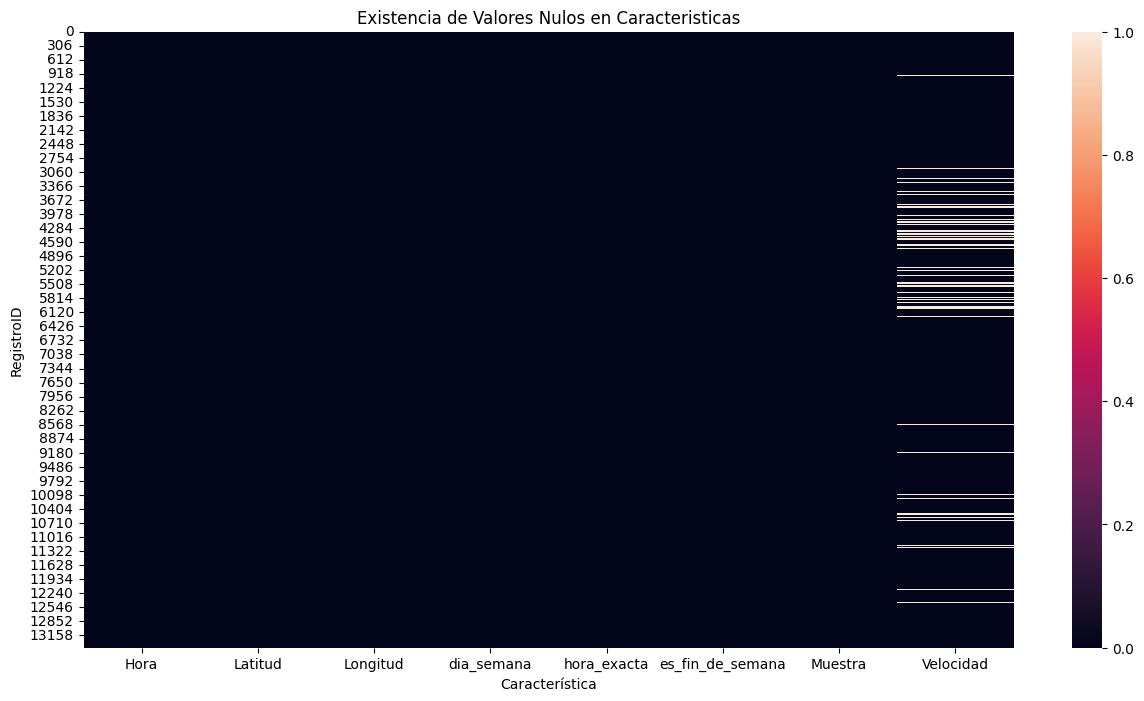

In [ ]:
  # @title
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

df = pd.read_csv("datos_limpios.csv")
datos = pd.DataFrame(df)
fig, axes = plt.subplots(figsize = (15, 8))
axes.set_title("Existencia de Valores Nulos en Caracteristicas")
sns.heatmap(datos.isnull())
axes.set_xlabel("Característica")
axes.set_ylabel("RegistroID")
print(df.shape)
####
# Convertir vacíos a NaN
df['Velocidad'] = pd.to_numeric(df['Velocidad'], errors='coerce')
# Eliminar velocidades imposibles
imputer = SimpleImputer(strategy='median')
df[['Velocidad']] = imputer.fit_transform(df[['Velocidad']])
archivo_salida = "datos_limpios.csv"
df.to_csv(archivo_salida, index=False)
print(f"Datos procesados guardados en: {archivo_salida}")
print(df.shape)

Funcion de la fórmula de Haversine

In [ ]:
# @title
# Función Haversine (esencial para precisión en km)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Radio de la Tierra en km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1-a))

Funcion que asigna los puntos GPS al segmento mas cercano, funcion distancia_punto_segmento.

In [ ]:
# @title
def distancia_punto_segmento(lat, lon, lat1, lon1, lat2, lon2):
    x0, y0 = lon, lat
    x1, y1 = lon1, lat1
    x2, y2 = lon2, lat2

    dx, dy = x2 - x1, y2 - y1
    if dx == 0 and dy == 0:
        return haversine(lat, lon, y1, x1)

    t = ((x0 - x1)*dx + (y0 - y1)*dy) / (dx*dx + dy*dy)
    t = max(0, min(1, t))

    x_proj, y_proj = x1 + t * dx, y1 + t * dy
    return haversine(lat, lon, y_proj, x_proj)


Crea los segmentos de la línea del Tren Ligero, asi como el calculo de la distancia promedio.

In [ ]:
# @title
# Crear segmentos entre estaciones consecutivas
estaciones = pd.read_csv("Estaciones.csv")
segmentos = []

for i in range(len(estaciones) - 1):
    a = estaciones.loc[i]
    b = estaciones.loc[i + 1]
    distancia_m = haversine(
        a['Latitud'], a['Longitud'],
        b['Latitud'], b['Longitud']
    )
    indice = i + 1
    segmentos.append({
        "segmento_id": indice,
        "estacion_inicio": a['Nombre'],
        "estacion_fin": b['Nombre'],
        "lat1": a['Latitud'],
        "lon1": a['Longitud'],
        "lat2": b['Latitud'],
        "lon2": b['Longitud'],
        "distancia_km": distancia_m
    })

segmentos = pd.DataFrame(segmentos)
print(segmentos[["segmento_id",
                 "estacion_inicio",
                 "estacion_fin",
                 #"distancia_m",
                 "distancia_km"]])

distancia_promedio_m = segmentos["distancia_km"].mean()
print(f"Distancia promedio entre estaciones: {distancia_promedio_m:.2f} km")
segmentos.to_csv('segmentos.csv', index=False)

    segmento_id   estacion_inicio      estacion_fin  distancia_km
0             1          Tasqueña        Las Torres      0.712435
1             2        Las Torres            Jardin      0.737694
2             3            Jardin         La Virgen      0.394101
3             4         La Virgen         Xotepingo      0.456989
4             5         Xotepingo     Nezahualpilli      0.456989
5             6     Nezahualpilli  Registro Federal      0.785406
6             7  Registro Federal         Textitlan      0.305781
7             8         Textitlan         El Vergel      1.475428
8             9         El Vergel    Estadio Azteca      0.611585
9            10    Estadio Azteca          Huipulco      0.788247
10           11          Huipulco            Xomali      1.129989
11           12            Xomali        Periferico      0.770965
12           13        Periferico           Tepepan      0.858846
13           14           Tepepan          La Noria      1.523253
14        

Se identifica los puntos de archivo con los datos GPS, para "asignarlos" al segmento que corresponde, donde se asigna un id a cada segmento asi como la distancia de cada uno de ellos.

In [ ]:
# @title
#####prueba
import pandas as pd
import numpy as np

# 1. Cargar datos
df_puntos = pd.read_csv('datos_limpios.csv')
df_segmentos = pd.read_csv('segmentos.csv')

# 2. Función para encontrar el segmento más cercano para un punto dado
def asignar_segmento(punto, segmentos):
    distancias = segmentos.apply(lambda s: distancia_punto_segmento(
        punto.Latitud, punto.Longitud, s.lat1, s.lon1, s.lat2, s.lon2), axis=1)

    idx_min = distancias.idxmin()
    return pd.Series([segmentos.loc[idx_min, 'segmento_id'], distancias[idx_min]])

# 3. Aplicar asignación
# Nota: Si tu archivo de puntos es muy grande, considera usar 'tqdm' para ver el progreso
resultados = df_puntos.apply(lambda p: asignar_segmento(p, df_segmentos), axis=1)
df_puntos[['segmento_id', 'distancia_al_segmento']] = resultados

# 4. Guardar
#df_puntos.to_csv('puntos_con_segmentos.csv', index=False)
df_puntos.to_csv('gps_con_segmento.csv', index=False)
print("Proceso completado. Archivo guardado como 'gps_con_segmentos.csv'")
####

Proceso completado. Archivo guardado como 'gps_con_segmentos.csv'


In [ ]:
# @title
#YANOSIRVE
#Se identifico cada punto GPS dentro del segmento correspondiente
gps = pd.read_csv("datos_limpios.csv")
gps["segmento_id"] = None
gps["dist_segmento_m"] = None
umbral = 50  # metros (puedes ajustar 20–30)
for i, p in gps.iterrows():
    distancias = segmentos.apply(
        lambda s: distancia_punto_segmento(p.Latitud, p.Longitud, s),axis=1)

    dist_min = distancias.min()
    idx = distancias.idxmin()
    #gps.loc[i, "segmento_id"] = segmentos.loc[idx, "segmento_id"]
    #gps.loc[i, "dist_segmento_m"] = round(distancias.min(), 2)
    if dist_min < umbral:
        gps.loc[i, "segmento_id"] = segmentos.loc[idx, "segmento_id"]
        gps.loc[i, "dist_segmento_m"] = round(dist_min, 2)
    else:
        # punto descartado
        gps.loc[i, "segmento_id"] = None
        gps.loc[i, "dist_segmento_m"] = None

gps.to_csv("gps_con_segmento.csv", index=False)
print("Archivo generado: gps_con_segmento.csv")
print(gps.shape)

Se elimina el "ruido de los puntos GPS, para que poder identificar de manera correcta el sentido del viaje y la cantidad de viajes realizados en ambos sentidos tanto de Tasqueña a Xochimilco asi como de Xochimilco a Tasqueña.

In [ ]:
# @title
from operator import methodcaller
import pandas as pd
import numpy as np

def procesar_viajes(df, seg_min=1, seg_max=17):
    # 1. Limpieza de ruido en segmento_id
    df['segmento_clean'] = (df['segmento_id'].rolling(window=5, center=True).median().round().fillna(df['segmento_id']).astype(int))
    df['diff'] = df['segmento_clean'].diff()

    # 2. Determinar la dirección (Ida o Vuelta)
    condiciones = [df['diff']> 0, df['diff'] < 0]
    valores = ['Ida', 'Vuelta']
    df['sentido'] = np.select(condiciones, valores, default= None)
    df['sentido'] = df['sentido'].ffill()
    #Correcion del primer registo
    if df.loc[1, 'diff'] == 0:
      df.loc[1, 'sentido'] = 'Ida'
      df['sentido'] = df['sentido'].ffill()

    # 3. Detectar llegada a extremos
    df['en_extremo'] = ((df['segmento_clean'] <= seg_min) | (df['segmento_clean'] >= seg_max))
    # 4. Nuevo viaje SOLO al salir del extremo
    df['inicio_viaje'] = False
    for i in range(1, len(df)):
      if (df.loc[i-1, 'en_extremo'] and not df.loc[i, 'en_extremo']):
        df.loc[i, 'inicio_viaje'] = True

    df['viaje_id'] = df['inicio_viaje'].cumsum()
    return df

  # Ejemplo de uso con tus datos
df = pd.read_csv("gps_con_segmento.csv")
df_resultado = procesar_viajes(df)
df_resultado = df.drop(columns=['Muestra'])
df_resultado.to_csv("gps_limpio.csv")

Detectar los datos atipicos en la velocidad, los cuales se tratan utilizando el valor de la mediana.

In [ ]:
# @title
import pandas as pd

#Cargar el archivo CSV
atipicos = pd.read_csv("gps_limpio.csv")
#Calcular Q1, Q3 e IQR
Q1 = atipicos['Velocidad'].quantile(0.25)
Q3 = atipicos['Velocidad'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
#Calcular la mediana
mediana = atipicos['Velocidad'].median()

# 6. Reemplazar outliers por la mediana
atipicos['Velocidad'] = atipicos['Velocidad'].apply(
    lambda x: mediana if x < limite_inferior or x > limite_superior else x)

# 8. Guardar el archivo resultante
atipicos.to_csv("gps_limpios.csv", index=False)

Se calculo el tiempo por segmento asi como el tiempo por viaje.

In [ ]:
# @title
#TiempoSegmento
# 1. Cargar los datasets
df_gps = pd.read_csv('gps_limpio.csv') # Tu dataset original
df_segmentos = pd.read_csv('segmentos.csv') # El catálogo con las distancias

# 2. Limpieza de ruido en el ID de segmento (Filtro de moda)
df_gps['segmento_clean'] = df_gps['segmento_id'].rolling(window=3, center=True).apply(lambda x: x.mode()[0]).fillna(df_gps['segmento_id'])

# 3. Filtrar para obtener solo registros en movimiento (Velocidad > 0)
UMBRAL_VEL = 0.01  # ajustable
df_movimiento = df_gps[df_gps['Velocidad'] > UMBRAL_VEL]

# 4. Agrupar para calcular la Velocidad Promedio por viaje y segmento
resumen_viajes = df_movimiento.groupby(['viaje_id', 'sentido', 'segmento_clean']).agg({
    'Velocidad': 'mean',
    'Hora': 'first',
    'dia_semana': 'first',
    'hora_exacta': 'first',
    'es_fin_de_semana': 'first'
}).reset_index()

resumen_viajes.rename(columns={'Velocidad': 'vel_promedio_movimiento', 'segmento_clean': 'segmento_id'}, inplace=True)
# 5. UNIR con el dataset de segmentos para traer la distancia_km oficial
# Esto busca el segmento_id en ambos archivos y añade la columna distancia_km
resumen_viajes = pd.merge(resumen_viajes, df_segmentos[['segmento_id','lat1','lon1','lat2','lon2','distancia_km']], on='segmento_id', how='left')
# 6. Calcular el tiempo_segmento (en minutos)
# Fórmula: (Distancia_km / Vel_promedio_kmh) * 60 minutos
resumen_viajes['tiempo_segmento'] = (resumen_viajes['distancia_km'] / resumen_viajes['vel_promedio_movimiento']) * 60
# 7. NUEVA COLUMNA: Tiempo Acumulado por Viaje
# Ordenamos por viaje y segmento para asegurar que la suma siga el orden lógico de la ruta
resumen_viajes = resumen_viajes.sort_values(by=['viaje_id', 'segmento_id'])
# Sumamos el tiempo de los segmentos conforme avanzan, reiniciando por cada viaje
resumen_viajes['tiempo_acumulado_viaje'] = resumen_viajes.groupby('viaje_id')['tiempo_segmento'].cumsum()
# Limpiar posibles errores (divisiones por cero o datos nulos)
resumen_viajes.replace([np.inf, -np.inf], 0, inplace=True)
resumen_viajes.fillna(0, inplace=True)
resumen_viajes.to_csv('tiempos_detallados_segmentos.csv', index=False)


**Hasta este punto solo fue limpieza de datos**

Con la información obtenida de tiempos promedio, se procedió a calcular el tiempo de llegada de una estación a otra.

*Se obtiene el factor de precipitación a partir de los datos recolectados*

/tmp/ipykernel_1090/3042256142.py:9: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Hora'] = pd.to_datetime(df['Hora'])


                     Hora    Latitud   Longitud  dia_semana  hora_exacta  \
0     2023-08-31 12:08:00  19.343720 -99.140580           3           12   
1     2023-08-31 12:09:00  19.343681 -99.140590           3           12   
2     2023-08-31 12:09:00  19.343717 -99.140587           3           12   
3     2023-08-31 12:09:00  19.343726 -99.140589           3           12   
4     2023-08-31 12:09:00  19.343714 -99.140607           3           12   
...                   ...        ...        ...         ...          ...   
13421 2023-11-08 18:45:00  19.343719 -99.140484           2           18   
13422 2023-11-08 18:45:00  19.343714 -99.140618           2           18   
13423 2023-11-08 18:45:00  19.343712 -99.140640           2           18   
13424 2023-11-08 18:45:00  19.343588 -99.140572           2           18   
13425 2023-11-08 18:45:00  19.343378 -99.140519           2           18   

       es_fin_de_semana  Muestra  Velocidad  segmento_id  \
0                     0    

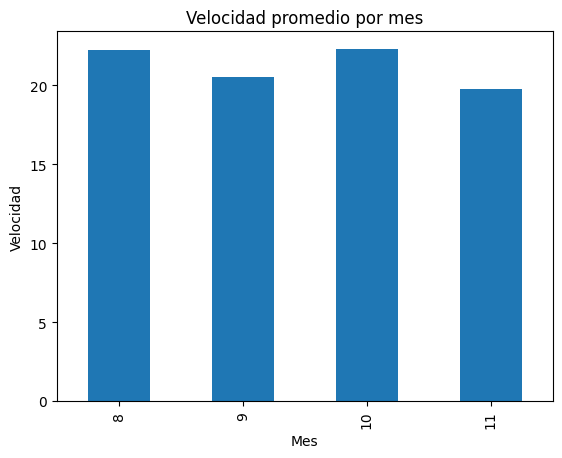

In [ ]:
# @title
##PERMITE DETERMINAR EL PERIODO DE LLUVIA A PARTIR DE LOS DATOS RECOLECTADOS
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

df = pd.read_csv("gps_con_segmento.csv")
df['Hora'] = pd.to_datetime(df['Hora'])
# Extraer mes
df['mes'] = df['Hora'].dt.month
# Clasificar lluvia vs seco
meses_lluvia = [5, 6, 7, 8, 9,10]
df['lluvia'] = df['mes'].isin(meses_lluvia).astype(int)
print(df)
# Velocidad promedio por mes
velocidad_mes = df.groupby('mes')['Velocidad'].mean()
print("\nVelocidad promedio por mes:")
print(velocidad_mes)
# Comparación lluvia vs seco
vel_seco = df[df['lluvia'] == 0]['Velocidad'].mean()
vel_lluvia = df[df['lluvia'] == 1]['Velocidad'].mean()
impacto = (vel_lluvia - vel_seco) / vel_seco
print("\nVelocidad promedio periodo seco:", round(vel_seco, 2))
print("Velocidad promedio periodo lluvia:", round(vel_lluvia, 2))
print("Impacto relativo:", round(impacto * 100, 2), "%")
# Estadística descriptiva por mes
print("\nEstadísticas por mes:")
print(df.groupby('mes')['Velocidad'].describe())
# Detección de anomalías (baja velocidad)
media_global = df['Velocidad'].mean()
df['anomalia'] = df['Velocidad'] < media_global * 0.8
anomalias_mes = df.groupby('mes')['anomalia'].mean()
print("\nProporción de anomalías por mes:")
print(anomalias_mes)
# Análisis por segmento
vel_segmento = df.groupby(['segmento_id', 'mes'])['Velocidad'].mean()
print("\nVelocidad por segmento y mes:")
print(vel_segmento)
# Factor dinámico de ajuste
factor_lluvia = vel_lluvia / vel_seco
print("\nFactor dinámico de lluvia:", round(factor_lluvia, 3))
# Aplicación al cálculo de ETA
def ajustar_velocidad(velocidad, mes):
    if mes in meses_lluvia:
        return velocidad * factor_lluvia
    return velocidad

df['velocidad_ajustada'] = df.apply(
    lambda row: ajustar_velocidad(row['Velocidad'], row['mes']), axis=1)
# Gracicas
plt.figure()
velocidad_mes.plot(kind='bar')
plt.title("Velocidad promedio por mes")
plt.xlabel("Mes")
plt.ylabel("Velocidad")
plt.show()


Mapea los puntos GPS de las estaciones.

In [ ]:
# @title
#Mapea los puntos GPS correspondientes a cada estación.
import folium

def cargar_dataset(path_csv):
    datos = pd.read_csv(path_csv)
    X = datos.iloc[:, [0,1,2]]
    return X

# Cargar dataset
coordenada = cargar_dataset("Estaciones.csv")
#coordenada = cargar_dataset("gps_con_segmento.csv")
# Crear mapa
# Crea el mapa base
mymap = folium.Map(location=[19.2797794, -99.1334534], zoom_start=13)
for index, row in coordenada.iterrows():
    lat = row['Latitud']
    lon = row['Longitud']
    #name = row['Nombre']
#Guarda el mapa
mymap.save("mapa_con_marcadores.html")
print("Se guardo con exito")

Se guardo con exito


Identifica si hubo o no precipitacion de acuerdo al mes del año

In [ ]:
# @title
import pandas as pd
import calendar
# Calcular densidad diaria (mm/día)
def dias_mes(anio, mes):
    return calendar.monthrange(anio, mes)[1]
# 1. Dataset principal
segmento = pd.read_csv("tiempos_detallados_segmentos.csv")
segmento["Hora"] = pd.to_datetime(segmento["Hora"],dayfirst=True, errors="coerce")
segmento["anio"] = segmento["Hora"].dt.year
segmento["mes_num"] = segmento["Hora"].dt.month
# 2. Dataset de lluvia
lluvia = pd.read_csv("lluviameses.csv")
# Normalizar texto
lluvia["Mes"] = lluvia["Mes"].str.lower().str.strip()
# Diccionario mes → número
mes_map = {
    "enero": 1, "febrero": 2, "marzo": 3, "abril": 4,
    "mayo": 5, "junio": 6, "julio": 7, "agosto": 8,
    "septiembre": 9, "octubre": 10, "noviembre": 11, "diciembre": 12}
lluvia["mes_num"] = lluvia["Mes"].map(mes_map)

# 3. Pasar formato ancho → largo
lluvia_long = lluvia.melt(
    id_vars=["Mes", "mes_num"],
    value_vars=["A2020", "A2021", "A2022", "A2023", "A2024"],
    var_name="anio",
    value_name="precip_mensual")
lluvia_long["anio"] = lluvia_long["anio"].str.replace("A", "").astype(int)
#Obtener la mediana para determinar si hubo lluvia o no
anio_seg = segmento['anio'].iloc[0]
mediana_precip = lluvia_long.loc[lluvia_long['anio'] == anio_seg, 'precip_mensual'].median()
# 4. Merge con dataset principal
segmento = segmento.merge(lluvia_long,on=["anio", "mes_num"], how="left")
#Obtener la mediana para determinar si hubo lluvia o no
segmento['precipitacion'] = (segmento["precip_mensual"] > mediana_precip).astype(int)
segmento.to_csv('tiempos_detallados_segmento.csv', index=False)

/tmp/ipykernel_3633/468452607.py:9: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  segmento["Hora"] = pd.to_datetime(segmento["Hora"],dayfirst=True, errors="coerce")


In [ ]:
# @title
#2. Asigna de acuerdo a la ubicacion la alcaldia correspondiente del tren ligero
import pandas as pd
import numpy as np
import calendar

segmentos = pd.read_csv("tiempos_detallados_segmento.csv")
factorpluvial= (1 - 0.205)
# Agregar columnas al dataset de segmentos
segmentos["velocidad"] = segmentos["vel_promedio_movimiento"]
segmentos.loc[segmentos["precipitacion"] == 1, "velocidad"] *= factorpluvial
# 6. Guardar resultado
segmentos = segmentos.drop(['Mes','precip_mensual','precipitacion'], axis=1)
segmentos.to_csv("segmentos_con_alcaldia_y_promedio.csv",index=False)
print("Archivo generado: segmentos_con_alcaldia_y_promedio.csv")

Archivo generado: segmentos_con_alcaldia_y_promedio.csv


Calcula el tiempo de llegada de una estación a otra considerando el factor lluvia, con la disminución de velocidad en caso de lluvia.

In [ ]:
# @title
df = pd.read_csv("segmentos_con_alcaldia_y_promedio.csv")
df['Hora'] = pd.to_datetime(df['Hora'], errors='coerce')
df = df.sort_values(by=['Hora', 'viaje_id', 'sentido'])

orden_estaciones = [
    "Estacion Tasqueña",
    "Estacion Las Torres",
    "Estacion Jardin",
    "Estacion La Virgen",
    "Estacion Xotepingo",
    "Estacion Nezahualpilli",
    "Estacion Registro Federal",
    "Estacion Textitlan",
    "Estacion El Vergel",
    "Estacion Estadio Azteca",
    "Estacion Huipulco",
    "Estacion Xomali",
    "Estacion Periferico",
    "Estacion Tepepan",
    "Estacion La Noria",
    "Estacion Huichapan",
    "Estacion Francisco Goitia",
    "Estacion Xochimilco"]
mapa_estaciones = {e: i for i, e in enumerate(orden_estaciones)}
# 2. Función ETA con lluvia
def calcular_eta_con_precipitacion(origen, destino):
    if origen not in mapa_estaciones or destino not in mapa_estaciones:
        raise ValueError("Estación inválida")

    idx_o = mapa_estaciones[origen]
    idx_d = mapa_estaciones[destino]

    if idx_o == idx_d:
        return {"eta_min": 0, "detalle": []}
    if idx_o < idx_d:
        sentido = "Ida"
        segmentos = list(range(idx_o, idx_d))
    else:
        sentido = "Vuelta"
        segmentos = list(range(idx_d, idx_o))

    eta_total = 0
    detalle = []
    for seg in segmentos:
        fila = df[
            (df["segmento_id"] == seg) &
            (df["sentido"] == sentido)]
        if fila.empty:
            continue

        fila = fila.iloc[0]
        velocidad = fila["velocidad"]  # km/h
        distancia = fila["distancia_km"]

        tiempo_horas = distancia / velocidad
        tiempo_min = tiempo_horas * 60
        eta_total += tiempo_min

        detalle.append({
            "segmento_id": seg,
            "desde": orden_estaciones[seg],
            "hasta": orden_estaciones[seg + 1],
            "distancia_km": round(distancia, 3),
            "velocidad_kmh": round(velocidad, 2),
            #"precipitacion": int(fila["precipitacion"]),
            "tiempo_min": round(tiempo_min, 2)
        })

    return {
        "origen": origen,
        "destino": destino,
        "sentido": sentido,
        "eta_min": round(eta_total, 2),
        "detalle": detalle}

# 3. Ejemplo de uso
if __name__ == "__main__":
    resultado = calcular_eta_con_precipitacion(
        "Estacion Tasqueña",
        "Estacion Xochimilco"
    )
print(f"\nETA TOTAL: {resultado['eta_min']} min")
print("Sentido: ", resultado['sentido'])
print("\nDetalle:")
for d in resultado['detalle']:
    print(f"{d['desde']} -> {d['hasta']} | "
        f"{d['tiempo_min']}  |"
        f"vel = {d['velocidad_kmh']} km/h")
print(f"\nETA TOTAL: {resultado['eta_min']} min")
print("Sentido: ", resultado['sentido'])

# Sección nueva

**Gráficas de Precipitación de 2020 a 2025 en la CDMX**

In [ ]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Leer el archivo CSV
df = pd.read_csv("lluviameses.csv")

# 2. Identificar solo las columnas de años (que empiezan con 'A')
anios = [col for col in df.columns if col.startswith('A')]

# Asegurar que los datos de los años sean numéricos
df[anios] = df[anios].apply(pd.to_numeric, errors='coerce')

# 3. Crear la gráfica
plt.figure(figsize=(11, 6))
for anio in anios:
    plt.plot(
        df["Mes"],
        df[anio],
        marker="o",
        label=str(anio))

# 4. Escala del eje Y (milímetros)
# Ahora max() funcionará correctamente sobre columnas numéricas
max_mm = df[anios].max().max()
ticks_mm = np.arange(0, max_mm + 20, 20)

plt.yticks(ticks_mm)

# 4. Formato de la gráfica
plt.xlabel("Mes")
plt.ylabel("Precipitación (mm)")
plt.title("Precipitación mensual por año CDMX")
plt.legend(title="Año")
plt.grid(True)

# 5. Ajustes finales y mostrar
plt.tight_layout()
plt.show()

**Gráficas de Precipitación de 2020 a 2025, con desviación estándar**

In [ ]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Leer archivo
df = pd.read_csv("lluviameses.csv")
# 2. Identificar columnas de años (filtrando solo las que empiezan con 'A')
anios = [col for col in df.columns if col.startswith('A')]
# 3. Calcular promedio y desviación estándar por mes asegurando valores numéricos
df[anios] = df[anios].apply(pd.to_numeric, errors='coerce')
df["promedio"] = df[anios].mean(axis=1)
df["std"] = df[anios].std(axis=1)

# 4. Preparar eje X
meses = df["Mes"]
x = range(len(meses))
# 5. Crear gráfica
plt.figure(figsize=(10, 5))
# Línea del promedio
plt.plot(x, df["promedio"], marker="o", label="Promedio mensual")
# Banda de desviación estándar
plt.fill_between(x,
    df["promedio"] - df["std"],
    df["promedio"] + df["std"],
    alpha=0.3,
    label="Desviación estándar")
# 6. Formato de la gráfica
plt.xticks(x, meses, rotation=45)
plt.xlabel("Mes")
plt.ylabel("Precipitación (mm)")
plt.title("Precipitación mensual promedio con desviación estándar")
plt.legend()
plt.grid(True)
# 7. Mostrar gráfica
plt.tight_layout()
plt.show()
# Crear gráfica
plt.bar(df['Mes'], df['promedio'], yerr=df['std'], capsize=5, color=['blue', 'green', 'red'], alpha=0.7)

# Personalización
plt.ylabel('Valores')
plt.title('Promedios con Desviación Estándar')
plt.show()

**Gráficas de Precipitación de 2020 a 2025, con promedios**

In [ ]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1. Leer archivo
# =========================
df = pd.read_csv("lluviameses.csv")

# ✅ SOLO columnas de años (evita ints_med u otras)
años = [col for col in df.columns if col.startswith("A")]

# Columnas de años
#años = df.columns.drop("Mes")

# Convertir a numérico por seguridad
df[años] = df[años].apply(pd.to_numeric, errors="coerce")
# =========================
# 2. Gráfica 1: Por año
# =========================
plt.figure(figsize=(11, 6))

for año in años:
    plt.plot(df["Mes"], df[año], marker="o", label=str(año))

# Escala eje Y
max_mm = df[años].max().max()
plt.yticks(np.arange(0, max_mm + 20, 20))

plt.xlabel("Mes")
plt.ylabel("Precipitación (mm)")
plt.title("Precipitación mensual por año")
plt.legend(title="Año")
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# 3. Cálculo X̄ y σ
# =========================
df["X_barra"] = df[años].mean(axis=1)
df["std"] = df[años].std(axis=1)

x = np.arange(len(df))

# =========================
# 4. Gráfica 2: X̄ (Promedio + σ)
# =========================
plt.figure(figsize=(11, 6))

plt.errorbar(
    x,
    df["X_barra"],
    yerr=df["std"],
    fmt="o-",
    capsize=5,
    label="X̄ ± σ"
)

# Escala eje Y
max_mm_xbar = (df["X_barra"] + df["std"]).max()
plt.yticks(np.arange(0, max_mm_xbar + 20, 20))

plt.xticks(x, df["Mes"], rotation=45)
plt.xlabel("Mes")
plt.ylabel("Precipitación (mm)")
plt.title("Gráfica X̄ de precipitación mensual CDMX")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

**Gráfica de precipitación por alcaldías**

In [ ]:
# @title
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# 1. Leer archivo
# ===============================
df = pd.read_csv("Xochimilco.csv")

# ===============================
# 2. Convertir fecha y limpiar datos
# ===============================
df["Fecha"] = pd.to_datetime(
    df["Fecha"],
    format="%d/%m/%Y",
    errors="coerce"
)

# IMPORTANTE: Convertir Precipitacion a numerico
df["Precipitacion"] = pd.to_numeric(df["Precipitacion"], errors="coerce")

# ===============================
# 3. Extraer anio y mes
# ===============================
df["Anio"] = df["Fecha"].dt.year
df["Mes"] = df["Fecha"].dt.month

# ===============================
# 4. Filtrar anios de interes
# ===============================
#anios_interes = [1963, 1985]
anios_interes = [2019, 2020, 2021,2022, 2024, 2025]
df = df[df["Anio"].isin(anios_interes)]

# ===============================
# 5. Nombres de meses
# ===============================
meses = {
    1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril",
    5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto",
    9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"
}

df["Mes_nombre"] = df["Mes"].map(meses)

# ===============================
# 6. Promedio mensual por anio
# ===============================
promedios = (
    df.groupby(["Anio", "Mes", "Mes_nombre"])["Precipitacion"]
      .mean()
      .reset_index()
      .sort_values("Mes")
)

# ===============================
# 7. Grafica
# ===============================
plt.figure(figsize=(11, 6))

for anio in anios_interes:
    datos = promedios[promedios["Anio"] == anio]
    plt.plot(
        datos["Mes_nombre"],
        datos["Precipitacion"],
        marker="o",
        label=str(anio)
    )
print(datos)
plt.xlabel("Mes")
plt.ylabel("Precipitacion promedio (mm)")
plt.title("Precipitacion mensual promedio (2019 - 2025) Alacaldía Xochimilco")
plt.legend(title="Anio")
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# ==============================
# 1. Cargar datos
# ==============================
df = pd.read_csv("dataset_segmentos_completo.csv")

orden_estaciones = [
    "Estacion Tasqueña",
    "Estacion Las Torres",
    "Estacion Jardin",
    "Estacion La Virgen",
    "Estacion Xotepingo",
    "Estacion Nezahualpilli",
    "Estacion Registro Federal",
    "Estacion Textitlan",
    "Estacion El Vergel",
    "Estacion Estadio Azteca",
    "Estacion Huipulco",
    "Estacion Xomali",
    "Estacion Periferico",
    "Estacion Tepepan",
    "Estacion La Noria",
    "Estacion Huichapan",
    "Estacion Francisco Goitia",
    "Estacion Xochimilco"
]

mapa_estaciones = {e: i for i, e in enumerate(orden_estaciones)}

# ==============================
# 2. Función ETA con lluvia
# ==============================
def calcular_eta_con_precipitacion(origen, destino):
    if origen not in mapa_estaciones or destino not in mapa_estaciones:
        raise ValueError("Estación inválida")

    idx_o = mapa_estaciones[origen]
    idx_d = mapa_estaciones[destino]

    if idx_o == idx_d:
        return {"eta_min": 0, "detalle": []}

    if idx_o < idx_d:
        sentido = "ida"
        segmentos = list(range(idx_o, idx_d))
    else:
        sentido = "vuelta"
        segmentos = list(range(idx_d, idx_o))

    eta_total = 0
    detalle = []

    for seg in segmentos:
        fila = df[
            (df["segmento_id"] == seg) &
            (df["sentido"] == sentido)
        ]

        if fila.empty:
            continue

        fila = fila.iloc[0]

        velocidad = fila["vel_promedio_movimiento"]  # km/h

        if fila["precipitacion"] == 1:
            velocidad *= 0.7  # reducción 30%

        distancia = fila["distancia_km"]

        tiempo_horas = distancia / velocidad
        tiempo_min = tiempo_horas * 60

        eta_total += tiempo_min

        detalle.append({
            "segmento_id": seg,
            "desde": orden_estaciones[seg],
            "hasta": orden_estaciones[seg + 1],
            "distancia_km": round(distancia, 3),
            "velocidad_kmh": round(velocidad, 2),
            "precipitacion": int(fila["precipitacion"]),
            "tiempo_min": round(tiempo_min, 2)
        })

    return {
        "origen": origen,
        "destino": destino,
        "sentido": sentido,
        "eta_min": round(eta_total, 2),
        "detalle": detalle
    }

# ==============================
# 3. Ejemplo de uso
# ==============================
if __name__ == "__main__":
    resultado = calcular_eta_con_precipitacion(
        "Estacion Tasqueña",
        "Estacion Huipulco"
    )

    print("\nETA TOTAL:", resultado["eta_min"], "min")
    print("Sentido:", resultado["sentido"])
    print("\nDetalle:")
    for d in resultado["detalle"]:
        print(
            f"{d['desde']} → {d['hasta']} | "
            f"{d['tiempo_min']} min | "
            f"vel={d['velocidad_kmh']} km/h | "
            f"lluvia={d['precipitacion']}"
        )

**Afluencia de pasajeros en el Sistema de Transporte Tren Ligero**

In [ ]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

df = pd.read_csv("afluencia_desglosada_tl_02_2026.csv")
df["fecha"] = pd.to_datetime(df["fecha"])
fecha_inicio = "2024-01-01"
fecha_fin = "2024-12-31"

df_filtrado = df[
    (df["fecha"] >= fecha_inicio) &
    (df["fecha"] <= fecha_fin)
]
print(df_filtrado)
# 4️⃣ Crear columna año-mes (equivalente a temporal_fecha)
df_filtrado["anio_mes"] = df_filtrado["fecha"].dt.to_period("M")

# 5️⃣ Agrupar por mes
afluencia_mensual = (
    df_filtrado
    .groupby("anio_mes")["afluencia"]
    .sum()
    .reset_index())

# 6️⃣ Convertir a datetime para graficar
afluencia_mensual["anio_mes"] = afluencia_mensual["anio_mes"].dt.to_timestamp()

# 7️⃣ Formato en miles (K)
def formato_k(x, pos):
    return f'{int(x/1000)}K'

# 8️⃣ Graficar
plt.figure(figsize=(10,5))
plt.plot(afluencia_mensual["anio_mes"], afluencia_mensual["afluencia"], marker='o')

plt.title("Afluencia de pasajeros durante el periodo 01-01-2025 a 31-12-2025")
plt.xlabel("Mes")
plt.ylabel("Afluencia de pasajeros (miles)")

plt.gca().yaxis.set_major_formatter(FuncFormatter(formato_k))

plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()

plt.show()